In [1]:
"""
Satellite Laser Altimeter Pointing Geometry
-------------------------------------------

This script evaluates:
1) Spacecraft velocity in a 474 km circular orbit
2) True kinematic point-ahead angle due to spacecraft motion
3) Commanded cross-track and forward pointing angles (1 km each)
4) Resulting total off-nadir angle
5) Relevance to specular reflection avoidance

All calculations are explicit and traceable.

168 cross tracks, 6m apart. grid is 6m.
"""

import numpy as np

# Physical constants
mu_earth = 3.986e14          # Earth gravitational parameter [m^3/s^2]
R_earth = 6378e3             # Earth radius [m]
c = 299_792_458              # Speed of light [m/s]

# Orbit parameters
altitude = 474e3             # Orbit altitude [m]
orbital_radius = R_earth + altitude

# Circular orbit velocity
v_sc = np.sqrt(mu_earth / orbital_radius)

# Light time and true point-ahead due to motion
round_trip_time = 2 * altitude / c
motion_displacement = v_sc * round_trip_time
motion_point_ahead_angle = motion_displacement / altitude

# Commanded offsets (given)

cross_track_offset = 500.0     # meters
forward_offset = 1000.0         # meters

theta_cross = np.arctan(cross_track_offset / altitude)
theta_forward = np.arctan(forward_offset / altitude)

# Combined off-nadir angle
theta_total = np.sqrt(theta_cross**2 + theta_forward**2)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------
print("\n--- ORBIT & MOTION ---")
print(f"Orbit altitude               : {altitude/1e3:.1f} km")
print(f"Spacecraft velocity          : {v_sc/1e3:.2f} km/s")
print(f"Round-trip light time        : {round_trip_time*1e3:.2f} ms")
print(f"Spacecraft motion in RT time : {motion_displacement:.1f} m")
print(f"Motion point-ahead angle     : {motion_point_ahead_angle*1e6:.1f} µrad")

print("\n--- COMMANDED POINTING ---")
print(f"Cross-track offset           : {cross_track_offset:.0f} m")
print(f"Cross-track angle            : {theta_cross*1e3:.2f} mrad "
      f"({np.degrees(theta_cross):.3f} deg)")

print(f"Forward offset               : {forward_offset:.0f} m")
print(f"Forward angle                : {theta_forward*1e3:.2f} mrad "
      f"({np.degrees(theta_forward):.3f} deg)")

print("\n--- RESULTING GEOMETRY ---")
print(f"Total off-nadir angle        : {theta_total*1e3:.2f} mrad "
      f"({np.degrees(theta_total):.3f} deg)")

print("\n--- INTERPRETATION ---")
print("• Required kinematic point-ahead is only ~50 µrad.")
print("• Commanded 1 km forward pointing is ~40× larger.")
print("• This is a deliberate choice to suppress specular reflection.")
print("• The resulting ~3 mrad off-nadir angle decisively avoids retro-reflection.")



--- ORBIT & MOTION ---
Orbit altitude               : 474.0 km
Spacecraft velocity          : 7.63 km/s
Round-trip light time        : 3.16 ms
Spacecraft motion in RT time : 24.1 m
Motion point-ahead angle     : 50.9 µrad

--- COMMANDED POINTING ---
Cross-track offset           : 500 m
Cross-track angle            : 1.05 mrad (0.060 deg)
Forward offset               : 1000 m
Forward angle                : 2.11 mrad (0.121 deg)

--- RESULTING GEOMETRY ---
Total off-nadir angle        : 2.36 mrad (0.135 deg)

--- INTERPRETATION ---
• Required kinematic point-ahead is only ~50 µrad.
• Commanded 1 km forward pointing is ~40× larger.
• This is a deliberate choice to suppress specular reflection.
• The resulting ~3 mrad off-nadir angle decisively avoids retro-reflection.


In [2]:
"""
168-Cross-Track Altimeter Geometry and Roughness Timing
------------------------------------------------------

- 168 cross tracks
- 6 m spacing
- 6 m grid
- Wavelength-mapped pointing (1035–1045 nm)
- Gardner-consistent roughness timing
"""

import numpy as np

# --------------------------------------------------
# Constants
# --------------------------------------------------
c = 299_792_458          # m/s
R = 474_000.0            # altitude [m]

# --------------------------------------------------
# Cross-track configuration
# --------------------------------------------------
N_tracks = 168
dx = 6.0                # cross-track spacing [m]
i0 = (N_tracks - 1) / 2

indices = np.arange(N_tracks)
x = (indices - i0) * dx             # cross-track position [m]
theta = x / R                       # off-nadir angle [rad]

# --------------------------------------------------
# Wavelength mapping
# --------------------------------------------------
lambda_min = 1035e-9
lambda_max = 1045e-9

wavelength = (
    lambda_min
    + (indices / (N_tracks - 1))
    * (lambda_max - lambda_min)
)

# --------------------------------------------------
# Surface roughness
# --------------------------------------------------
sigma_h = 0.20          # RMS surface roughness [m]

sigma_t_rough = (2 * sigma_h / c) / np.cos(theta)

# --------------------------------------------------
# Print representative samples
# --------------------------------------------------
print("\nIndex | Wavelength (nm) | X (m) | Angle (mrad) | Roughness jitter (ps)")
print("----------------------------------------------------------------------")

for i in [0, 42, 84, 126, 167]:
    print(
        f"{i:5d} | "
        f"{wavelength[i]*1e9:9.3f} | "
        f"{x[i]:6.1f} | "
        f"{theta[i]*1e3:8.3f} | "
        f"{sigma_t_rough[i]*1e12:10.3f}"
    )

# --------------------------------------------------
# Interpretation
# --------------------------------------------------
print("\nInterpretation:")
print("• Cross-track angle varies linearly with wavelength.")
print("• Maximum off-nadir angle is ~1 mrad.")
print("• Surface roughness timing is nearly constant across beams.")
print("• Second-order increase appears at large cross-track angles.")
print("• Geometry-induced errors, not roughness, dominate beam-to-beam variation.")



Index | Wavelength (nm) | X (m) | Angle (mrad) | Roughness jitter (ps)
----------------------------------------------------------------------
    0 |  1035.000 | -501.0 |   -1.057 |   1334.257
   42 |  1037.515 | -249.0 |   -0.525 |   1334.257
   84 |  1040.030 |    3.0 |    0.006 |   1334.256
  126 |  1042.545 |  255.0 |    0.538 |   1334.257
  167 |  1045.000 |  501.0 |    1.057 |   1334.257

Interpretation:
• Cross-track angle varies linearly with wavelength.
• Maximum off-nadir angle is ~1 mrad.
• Surface roughness timing is nearly constant across beams.
• Second-order increase appears at large cross-track angles.
• Geometry-induced errors, not roughness, dominate beam-to-beam variation.


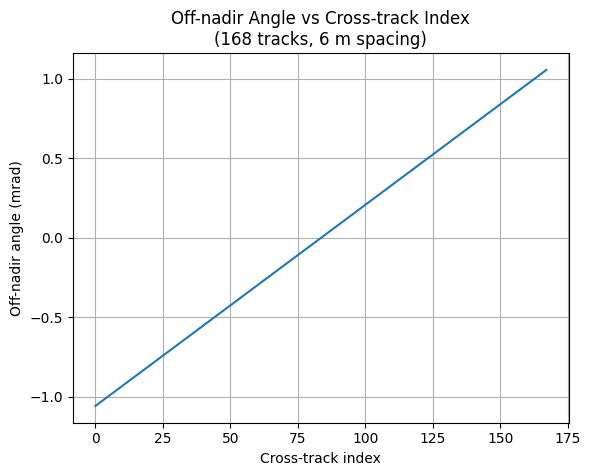

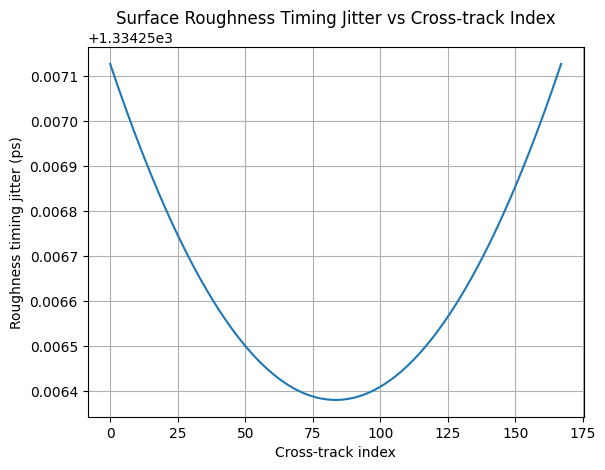

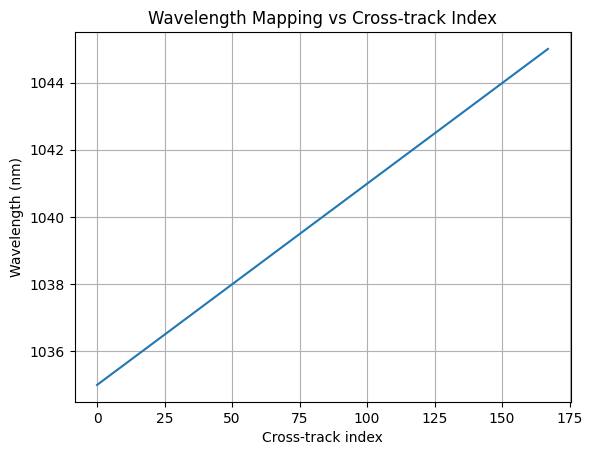

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Constants and configuration
# --------------------------------------------------
c = 299_792_458          # speed of light [m/s]
R = 474_000.0            # altitude [m]

N_tracks = 168
dx = 6.0                # cross-track spacing [m]
i0 = (N_tracks - 1) / 2

indices = np.arange(N_tracks)

# Cross-track position and angle
x = (indices - i0) * dx             # meters
theta = x / R                       # radians (small-angle approx)

# Wavelength mapping
lambda_min = 1035e-9
lambda_max = 1045e-9
wavelength = (
    lambda_min
    + (indices / (N_tracks - 1))
    * (lambda_max - lambda_min)
)

# Surface roughness
sigma_h = 0.20          # RMS roughness [m]
sigma_t_rough = (2 * sigma_h / c) / np.cos(theta)

# --------------------------------------------------
# Plot 1: Off-nadir angle vs cross-track index
# --------------------------------------------------
plt.figure()
plt.plot(indices, theta * 1e3)
plt.xlabel("Cross-track index")
plt.ylabel("Off-nadir angle (mrad)")
plt.title("Off-nadir Angle vs Cross-track Index\n(168 tracks, 6 m spacing)")
plt.grid(True)
plt.show()

# --------------------------------------------------
# Plot 2: Roughness-induced timing jitter vs index
# --------------------------------------------------
plt.figure()
plt.plot(indices, sigma_t_rough * 1e12)
plt.xlabel("Cross-track index")
plt.ylabel("Roughness timing jitter (ps)")
plt.title("Surface Roughness Timing Jitter vs Cross-track Index")
plt.grid(True)
plt.show()

# --------------------------------------------------
# Plot 3: Wavelength vs cross-track index
# --------------------------------------------------
plt.figure()
plt.plot(indices, wavelength * 1e9)
plt.xlabel("Cross-track index")
plt.ylabel("Wavelength (nm)")
plt.title("Wavelength Mapping vs Cross-track Index")
plt.grid(True)
plt.show()
